### Importación de Librerías y Configuración del Entorno
Se define el entorno de inferencia y se cargan librerías para métricas y visualización.
El dispositivo GPU/CPU se detecta automáticamente.


In [31]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    f1_score,
)
import joblib

# Permitir importar desde src/
BASE_DIR = Path("..")
sys.path.append(str(BASE_DIR))

from src.model import Autoencoder

# Configuración gráfica
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Dispositivo para inferencia: {device}")

PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"

⚡ Dispositivo para inferencia: cpu


In [32]:
# ---------------------------------------------------------
# 1. Cargar datos procesados y sus etiquetas reales
# ---------------------------------------------------------
X_test = np.load(PROCESSED_DATA_PATH / "X_test.npy")
y_test = np.load(PROCESSED_DATA_PATH / "y_test.npy")

X_val = np.load(PROCESSED_DATA_PATH / "X_val.npy")
y_val = np.load(PROCESSED_DATA_PATH / "y_val.npy")

print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Distribución de etiquetas y_test -> Lícitas (0): {(y_test == 0).sum()} | Ilícitas (1): {(y_test == 1).sum()}")

Dimensiones de X_test: (57109, 30)
Distribución de etiquetas y_test -> Lícitas (0): 56863 | Ilícitas (1): 246


In [33]:
# ---------------------------------------------------------
# 2. Cargar la arquitectura e hiperparámetros del modelo
# ---------------------------------------------------------
INPUT_DIM = X_test.shape[1]

checkpoint = torch.load(MODELS_DIR / "autoencoder_creditcard.pth", map_location=device)
model = Autoencoder(
    input_dim=INPUT_DIM,
    bottleneck_dim=checkpoint.get("bottleneck_dim", 14),
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

model.eval()
print("✅ Modelo de Credit Card cargado exitosamente en modo evaluación.")

✅ Modelo de Credit Card cargado exitosamente en modo evaluación.


In [34]:
# ---------------------------------------------------------
# 3. Inferencia y Cálculo del Error de Reconstrucción (MSE)
# ---------------------------------------------------------
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)

with torch.no_grad():
    X_test_reconstructed = model(X_test_tensor).cpu().numpy()
    X_val_reconstructed = model(X_val_tensor).cpu().numpy()

# Error Cuadrático Medio (MSE) por muestra en el espacio de características escalado
reconstruction_errors_test = np.mean(np.square(X_test - X_test_reconstructed), axis=1)
reconstruction_errors_val = np.mean(np.square(X_val - X_val_reconstructed), axis=1)

print(f"\nError de Reconstrucción Promedio Test: {reconstruction_errors_test.mean():.6f}")
print(f"  └─ Promedio en Lícitas (Clase 0) Test: {reconstruction_errors_test[y_test == 0].mean():.6f}")
print(f"  └─ Promedio en Ilícitas (Clase 1) Test: {reconstruction_errors_test[y_test == 1].mean():.6f}")
print(f"Error de Reconstrucción Promedio Val:  {reconstruction_errors_val.mean():.6f}")
print(f"  └─ Promedio en Lícitas (Clase 0) Val:  {reconstruction_errors_val[y_val == 0].mean():.6f}")
print(f"  └─ Promedio en Ilícitas (Clase 1) Val:  {reconstruction_errors_val[y_val == 1].mean():.6f}")


Error de Reconstrucción Promedio Test: 0.172564
  └─ Promedio en Lícitas (Clase 0) Test: 0.109243
  └─ Promedio en Ilícitas (Clase 1) Test: 14.809408
Error de Reconstrucción Promedio Val:  0.174703
  └─ Promedio en Lícitas (Clase 0) Val:  0.107316
  └─ Promedio en Ilícitas (Clase 1) Val:  15.751208


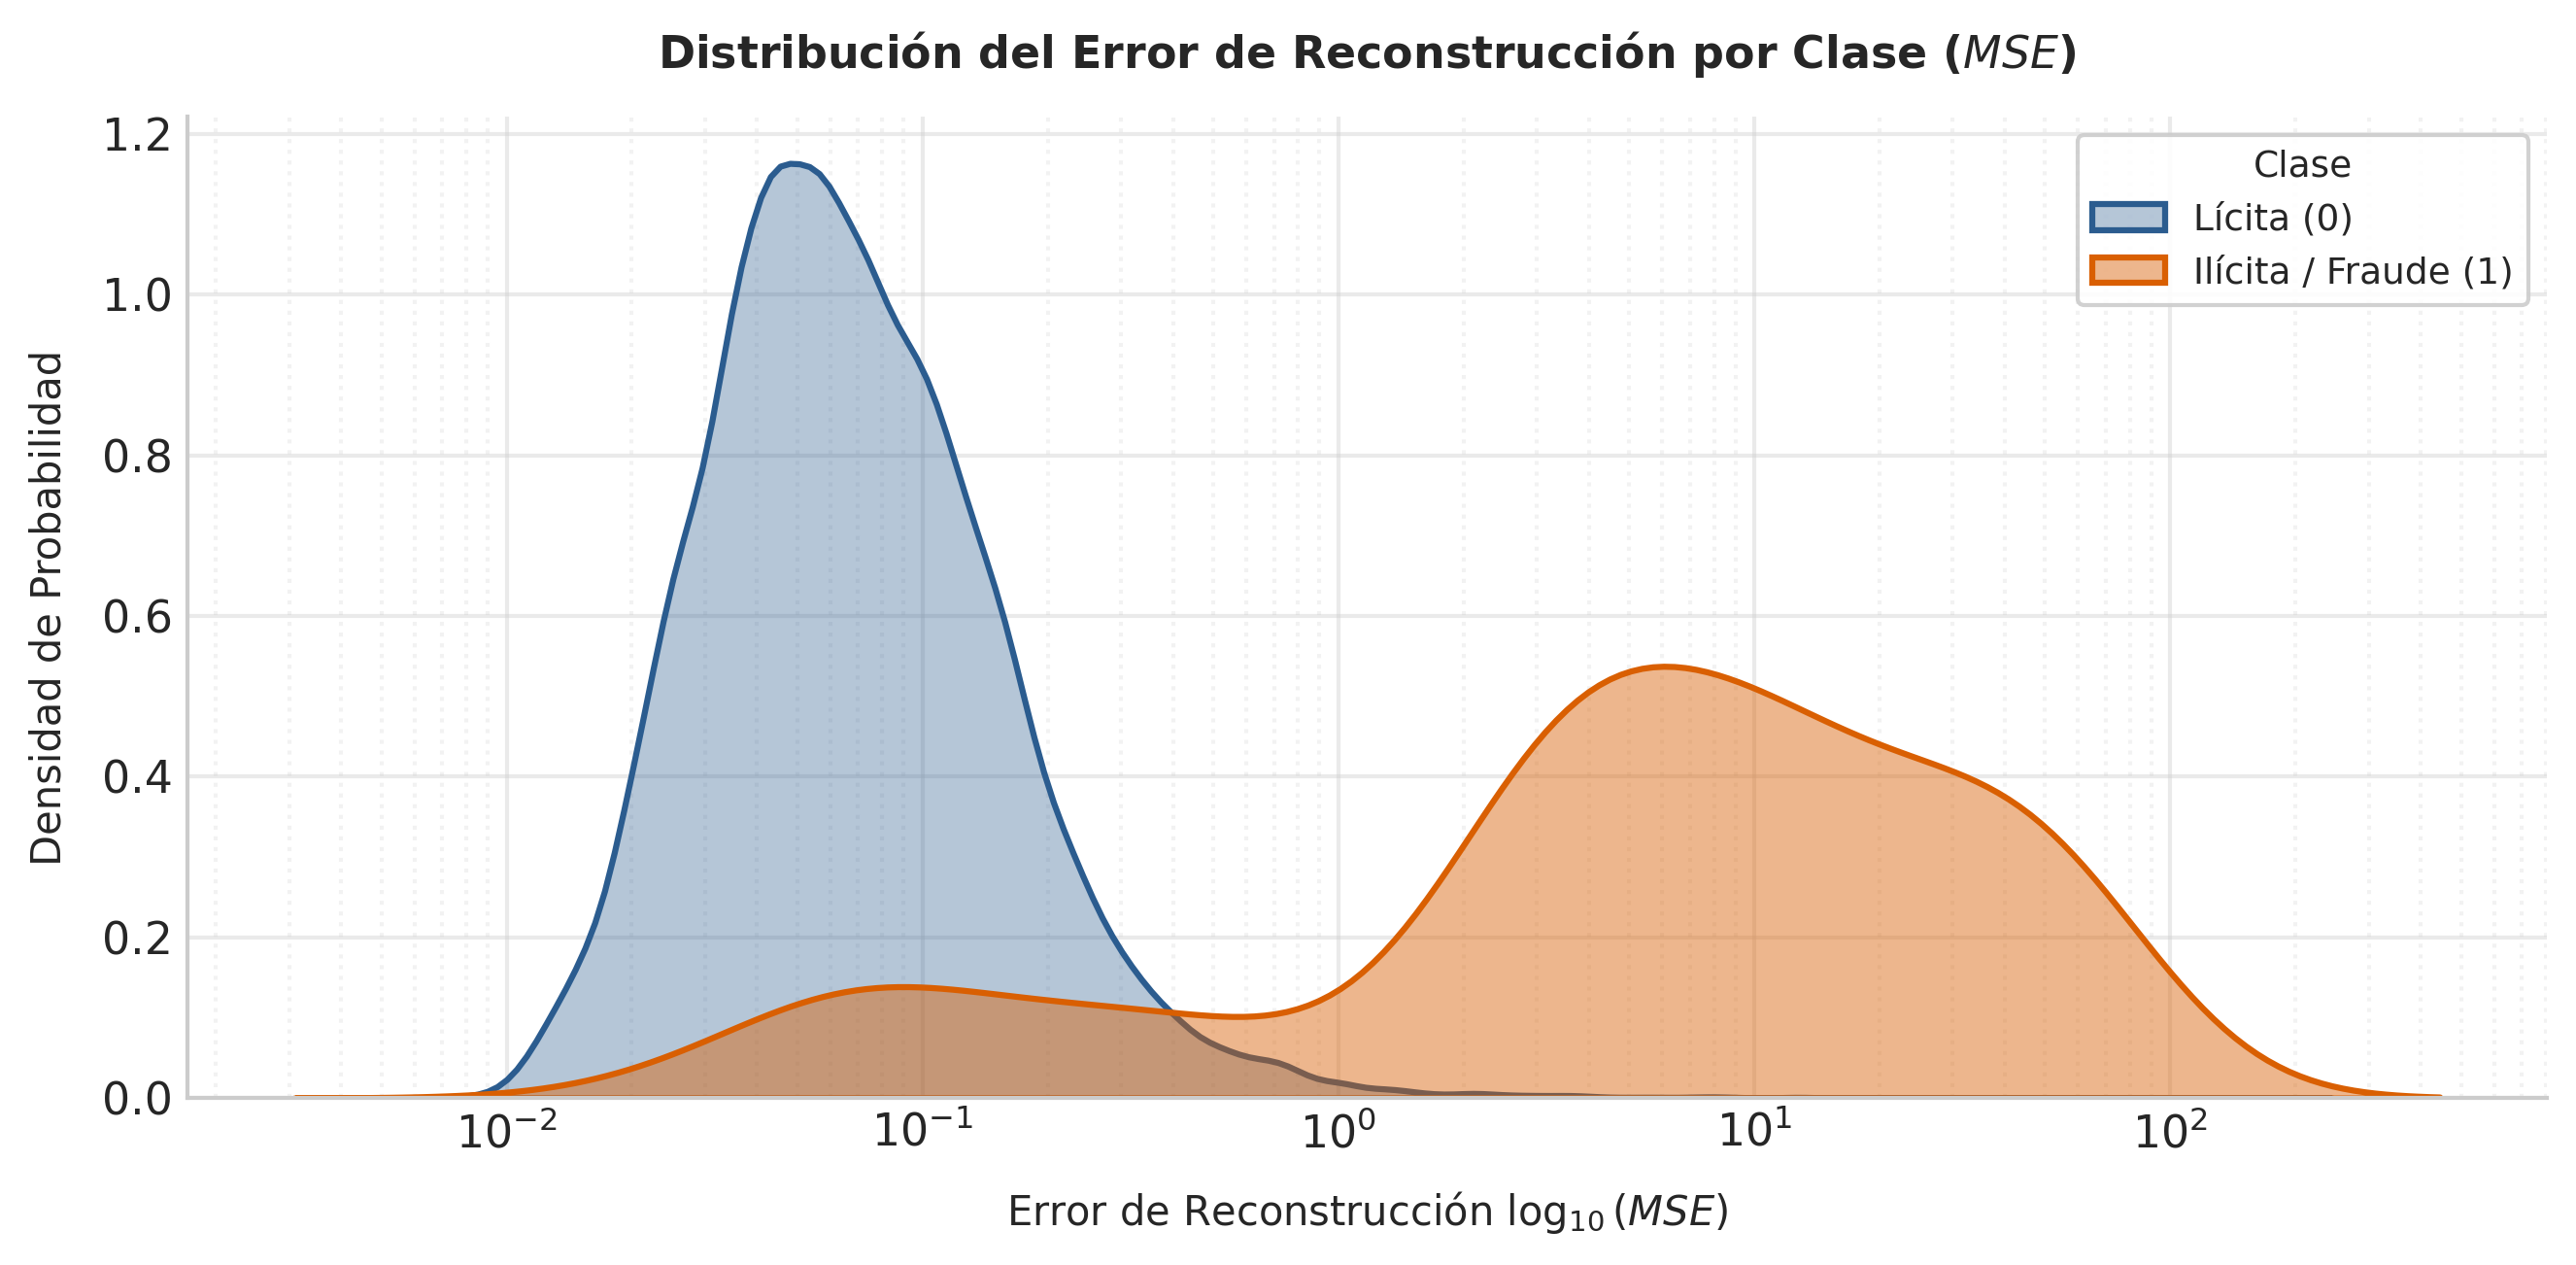

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo global académico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=300)

# Paleta semántica coherente con todo el proyecto
color_licita = '#2b5c8f'   # Azul sobrio
color_ilicita = '#d95f02'  # Naranja/Rojo de alerta

# Estimación de Densidad Kernel (KDE) con transformación logarítmica en el eje X
sns.kdeplot(
    data=reconstruction_errors_test[y_test == 0], 
    label="Lícita (0)", 
    color=color_licita, 
    fill=True, 
    alpha=0.35, 
    linewidth=1.5,
    log_scale=True, 
    ax=ax
)

sns.kdeplot(
    data=reconstruction_errors_test[y_test == 1], 
    label="Ilícita / Fraude (1)", 
    color=color_ilicita, 
    fill=True, 
    alpha=0.45, 
    linewidth=1.5,
    log_scale=True, 
    ax=ax
)

# Etiquetas y títulos para publicación
ax.set_title("Distribución del Error de Reconstrucción por Clase ($MSE$)", fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel("Error de Reconstrucción $\\log_{10}(MSE)$", fontsize=10, labelpad=8)
ax.set_ylabel("Densidad de Probabilidad", fontsize=10, labelpad=8)

# Rejillas tenue para facilitar lectura de magnitudes
ax.grid(True, which='major', linestyle='-', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.25)
ax.set_axisbelow(True)

# Limpieza de bordes (Chart Junk)
sns.despine(top=True, right=True)

# Leyenda formal
ax.legend(title="Clase", title_fontsize='9', frameon=True, facecolor='white', framealpha=0.9, fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()


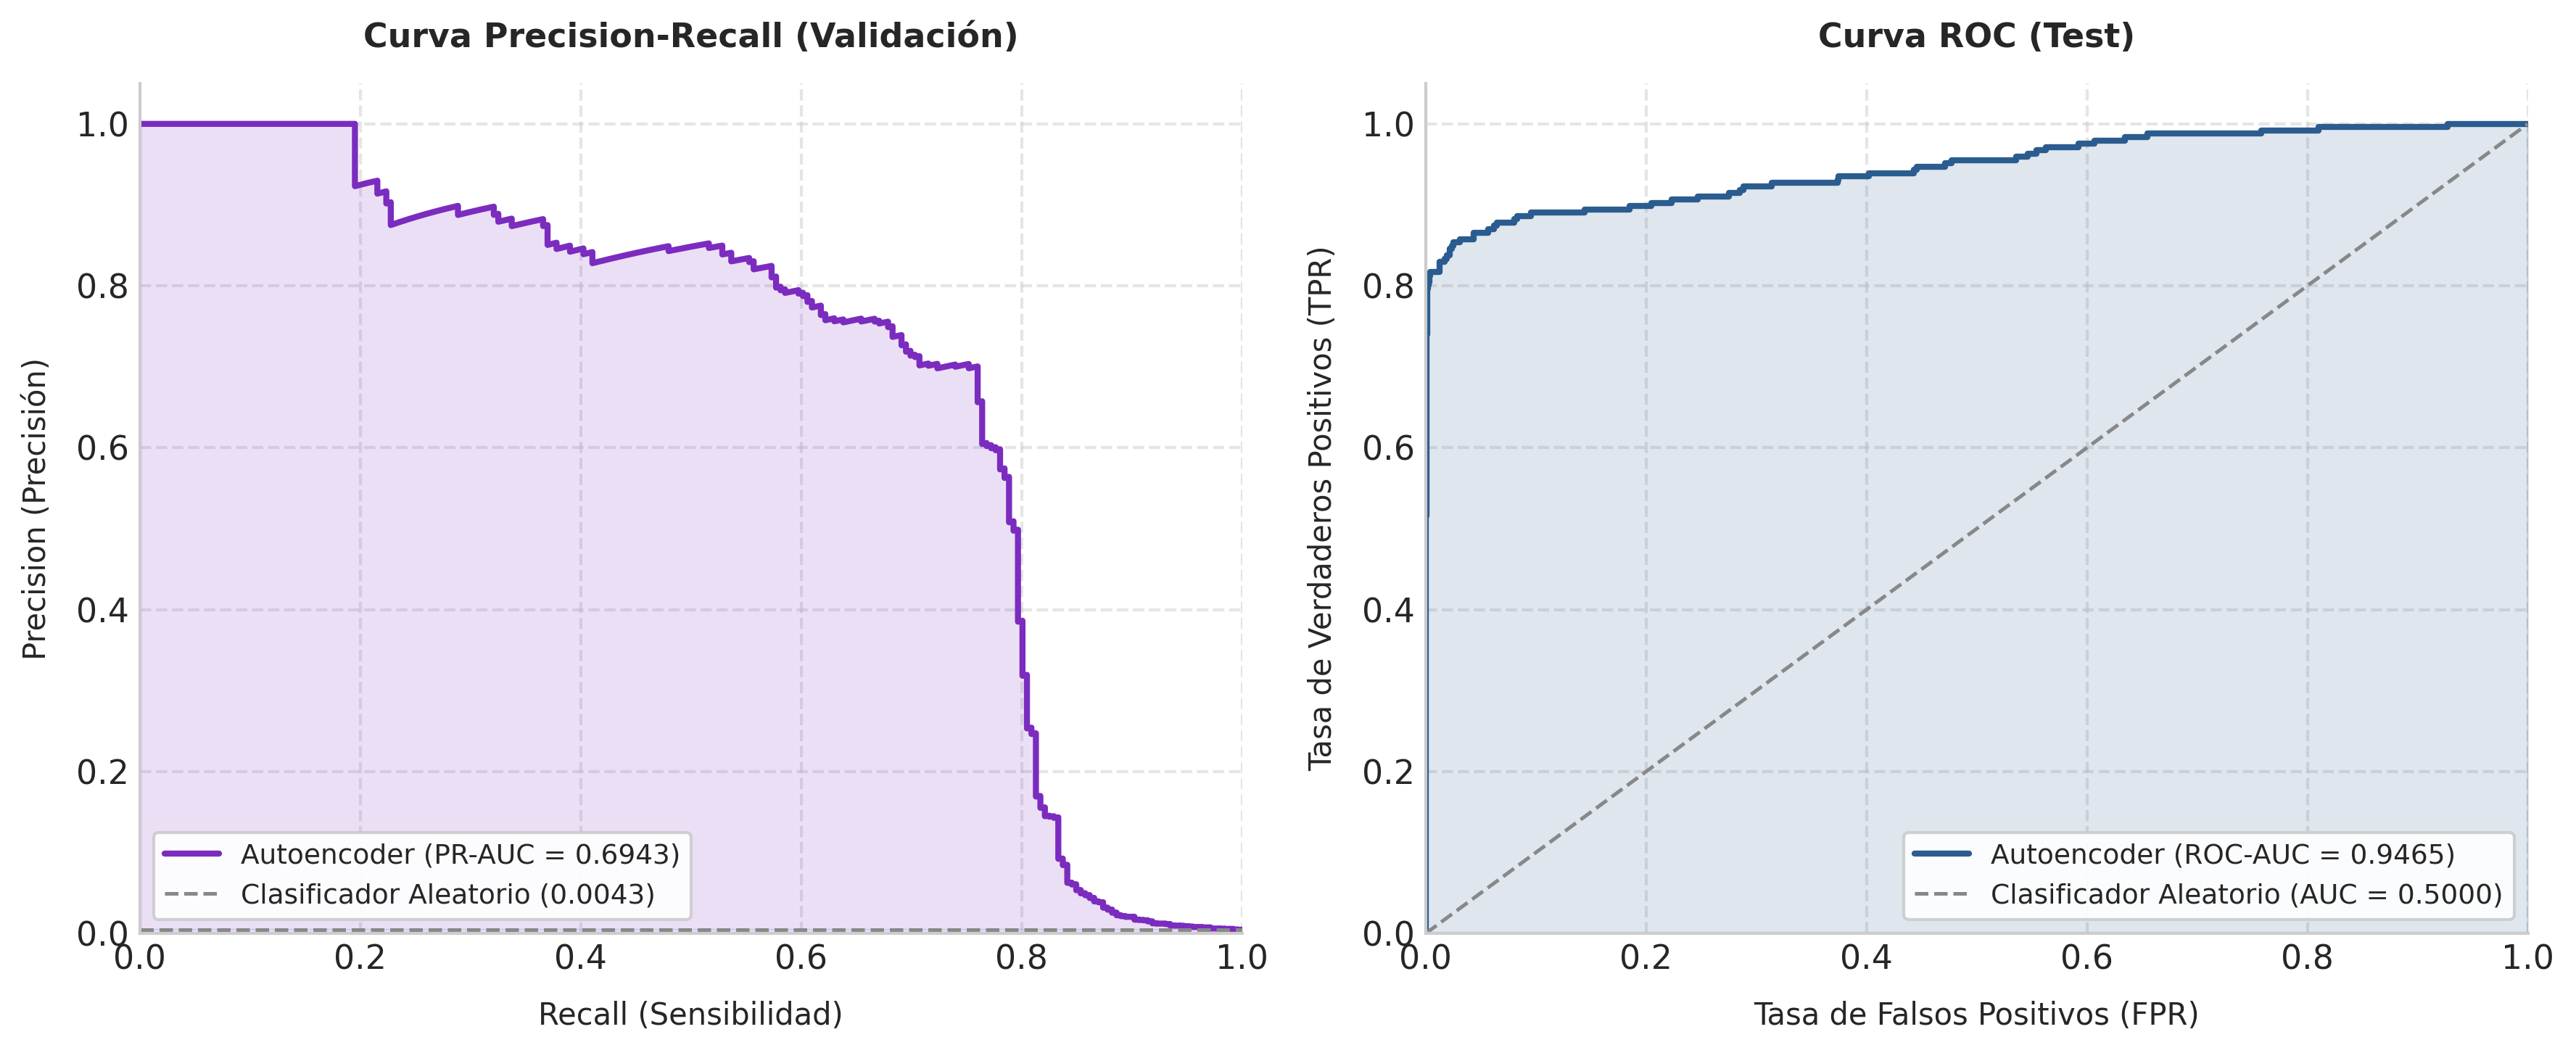

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc, roc_auc_score

# Cálculo de métricas
precision_v, recall_v, _ = precision_recall_curve(y_val, reconstruction_errors_val)
pr_auc_val = auc(recall_v, precision_v)

fpr, tpr, _ = roc_curve(y_test, reconstruction_errors_test)
roc_auc_test = roc_auc_score(y_test, reconstruction_errors_test)

# Cálculo de la línea base para PR (Prevalencia de la clase positiva en Validación)
no_skill_pr = (y_val == 1).sum() / len(y_val)

# Estilo global académico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

color_pr = '#7b2cbf'   # Púrpura sobrio
color_roc = '#2b5c8f'  # Azul sobrio

# --- 1. Curva Precision-Recall (Validación) ---
ax1 = axes[0]
ax1.plot(recall_v, precision_v, color=color_pr, lw=2, label=f'Autoencoder (PR-AUC = {pr_auc_val:.4f})')
ax1.axhline(y=no_skill_pr, color='#888888', linestyle='--', lw=1.2, label=f'Clasificador Aleatorio ({no_skill_pr:.4f})')
ax1.fill_between(recall_v, precision_v, no_skill_pr, color=color_pr, alpha=0.15)

ax1.set_title("Curva Precision-Recall (Validación)", fontsize=11, fontweight='bold', pad=12)
ax1.set_xlabel("Recall (Sensibilidad)", fontsize=10, labelpad=8)
ax1.set_ylabel("Precision (Precisión)", fontsize=10, labelpad=8)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
ax1.legend(loc="lower left", frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

# --- 2. Curva ROC (Test) ---
ax2 = axes[1]
ax2.plot(fpr, tpr, color=color_roc, lw=2, label=f'Autoencoder (ROC-AUC = {roc_auc_test:.4f})')
ax2.plot([0, 1], [0, 1], color='#888888', linestyle='--', lw=1.2, label='Clasificador Aleatorio (AUC = 0.5000)')
ax2.fill_between(fpr, tpr, color=color_roc, alpha=0.15)

ax2.set_title("Curva ROC (Test)", fontsize=11, fontweight='bold', pad=12)
ax2.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=10, labelpad=8)
ax2.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=10, labelpad=8)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
ax2.legend(loc="lower right", frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

# Eliminar bordes innecesarios (Chart Junk)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Selección del Umbral Óptimo (τ) en Validación
Se obtiene el umbral que maximiza el F1 score sobre validación.
Este umbral se usa luego para clasificar el conjunto de test.

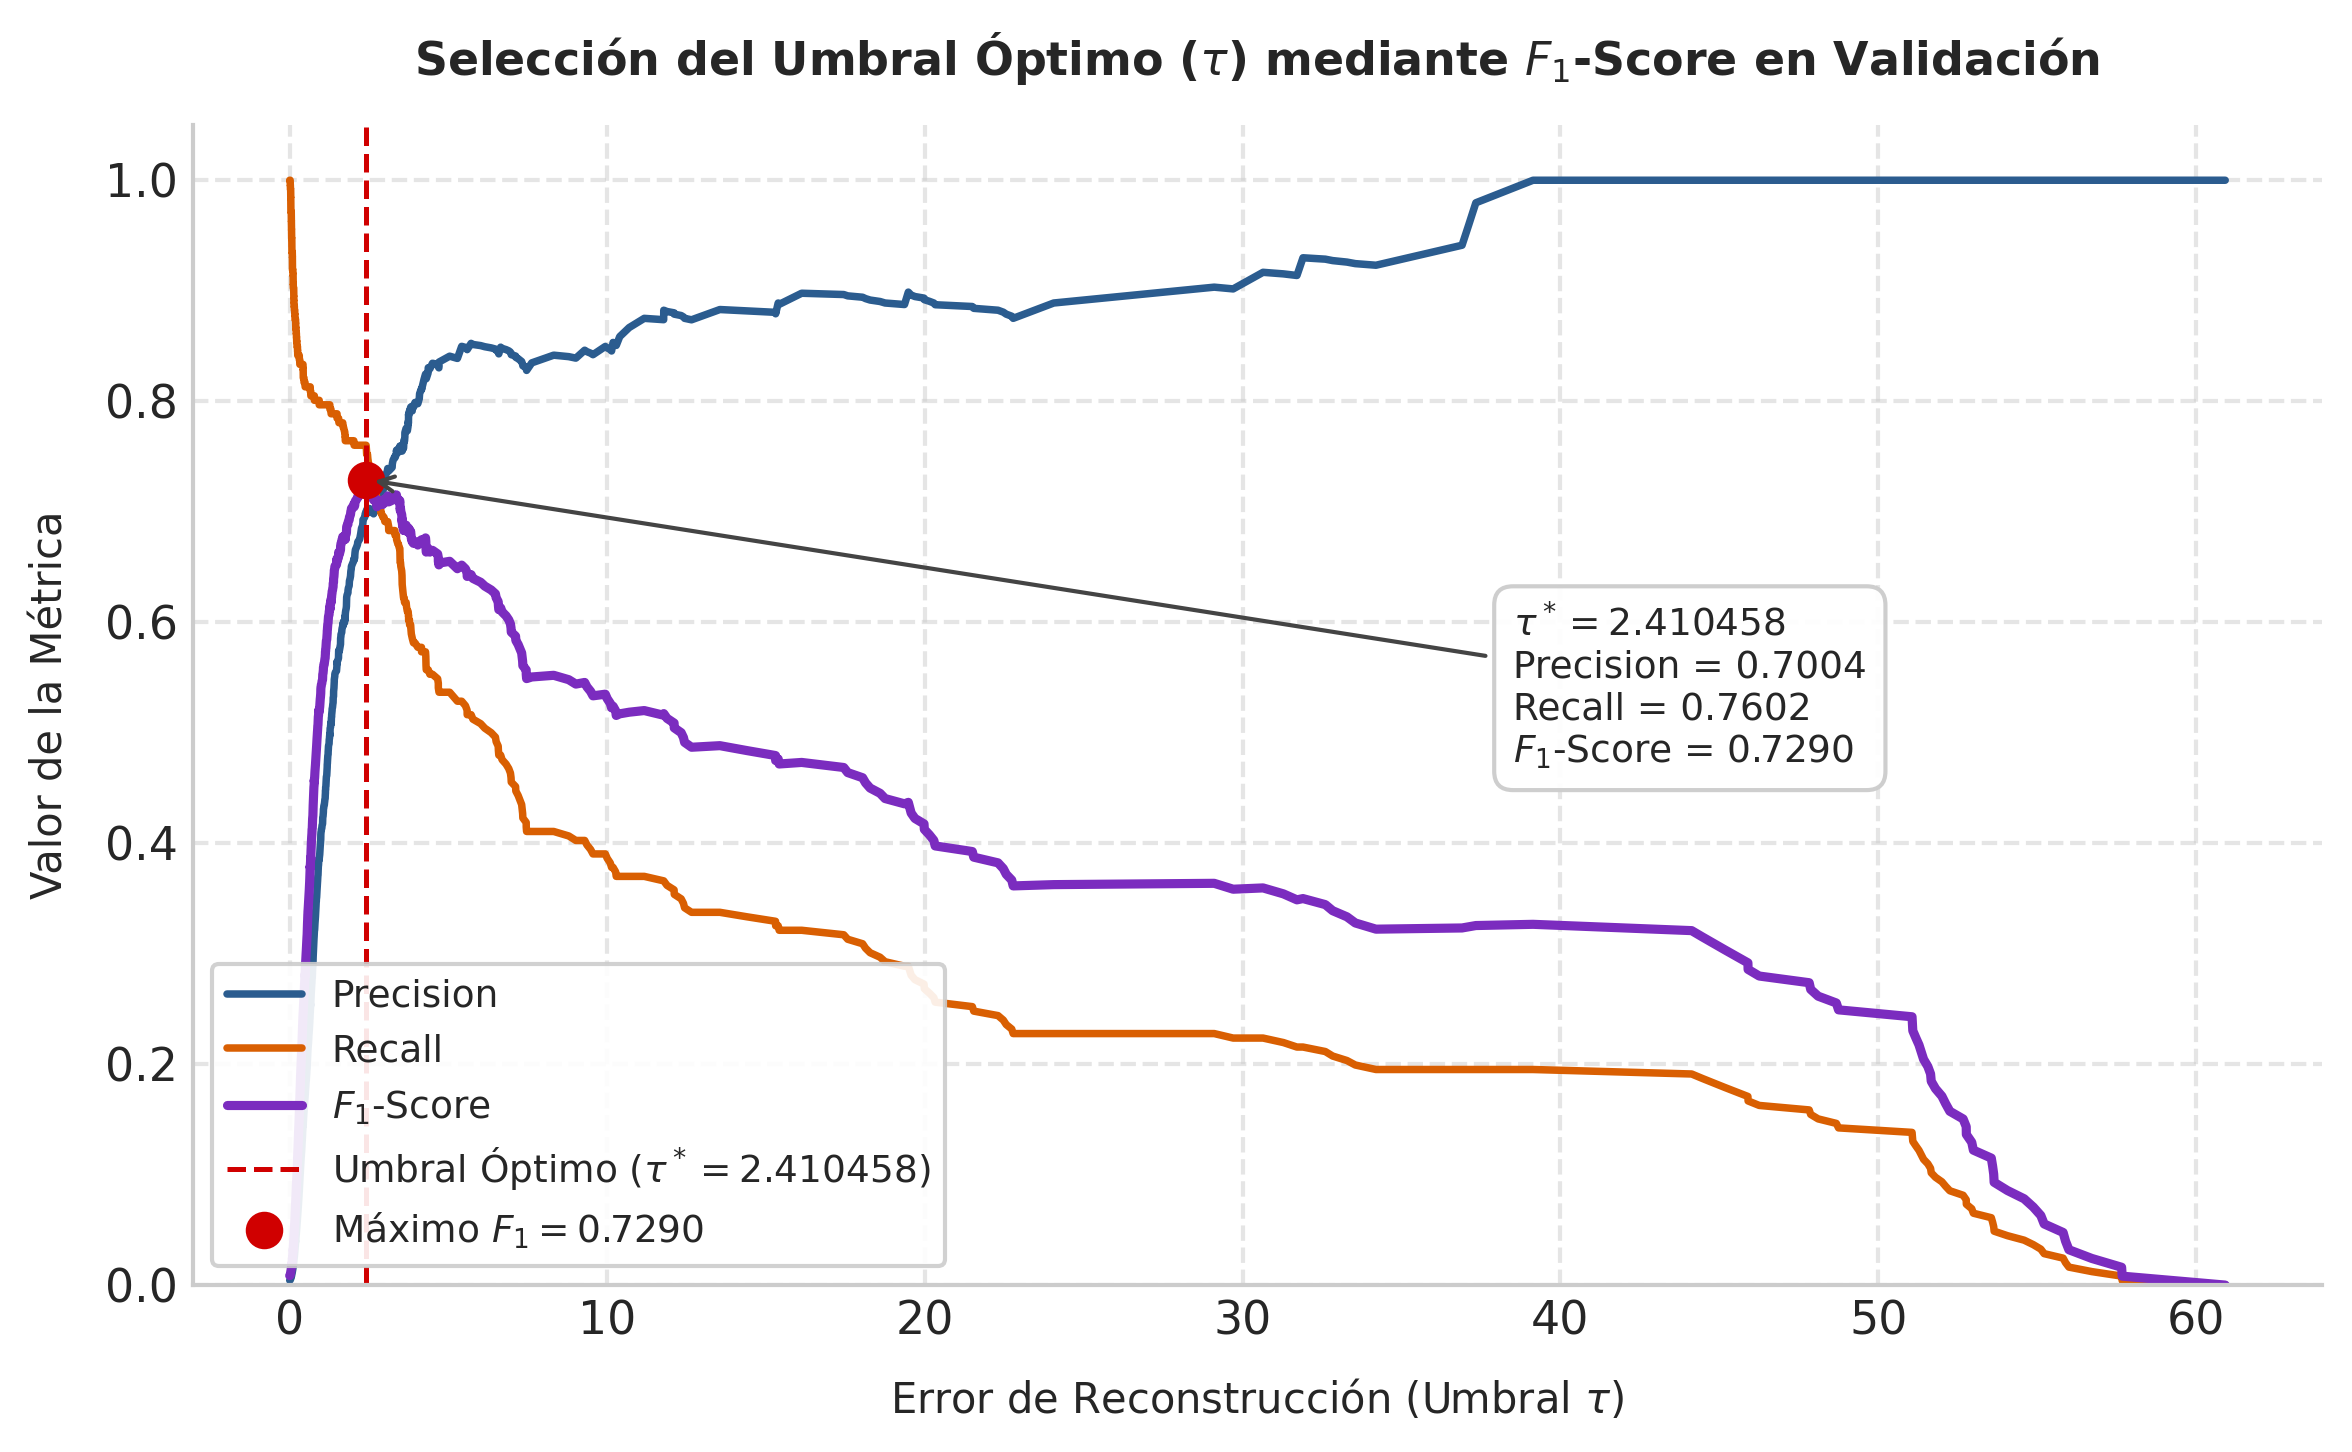

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Estilo global académico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Graficar la evolución de Precision, Recall y F1 en función del Umbral
ax.plot(thresholds_v, precision_valid, color='#2b5c8f', lw=1.8, label='Precision')
ax.plot(thresholds_v, recall_valid, color='#d95f02', lw=1.8, label='Recall')
ax.plot(thresholds_v, f1_scores, color='#7b2cbf', lw=2.2, label='$F_1$-Score')

# Marcar la línea vertical y el punto en el umbral óptimo
ax.axvline(x=optimal_threshold, color='#d00000', linestyle='--', lw=1.2, 
           label=f'Umbral Óptimo ($\\tau^* = {optimal_threshold:.6f}$)')
ax.plot(optimal_threshold, best_f1, marker='o', markersize=8, color='#d00000', 
        linestyle='None', label=f'Máximo $F_1 = {best_f1:.4f}$')

# Formato formal de ejes y títulos
ax.set_title("Selección del Umbral Óptimo ($\\tau$) mediante $F_1$-Score en Validación", fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel("Error de Reconstrucción (Umbral $\\tau$)", fontsize=10, labelpad=8)
ax.set_ylabel("Valor de la Métrica", fontsize=10, labelpad=8)
ax.set_ylim([0.0, 1.05])

# Anotación científica flotante con los valores exactos
anotacion = (f"$\\tau^* = {optimal_threshold:.6f}$\n"
             f"Precision = {precision_valid[best_idx]:.4f}\n"
             f"Recall = {recall_valid[best_idx]:.4f}\n"
             f"$F_1$-Score = {best_f1:.4f}")

ax.annotate(anotacion, 
            xy=(optimal_threshold, best_f1), 
            xytext=(0.62, 0.45), 
            textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1, color='#444444'),
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.95))

# Cuadrícula y limpieza de bordes
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Leyenda
ax.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()

### Evaluación Final en Test y Métricas
Se evalúan precisión, recall, F1 y curvas ROC/PR en el conjunto de prueba.
También se generan matrices de confusión para validar el desempeño por clase.

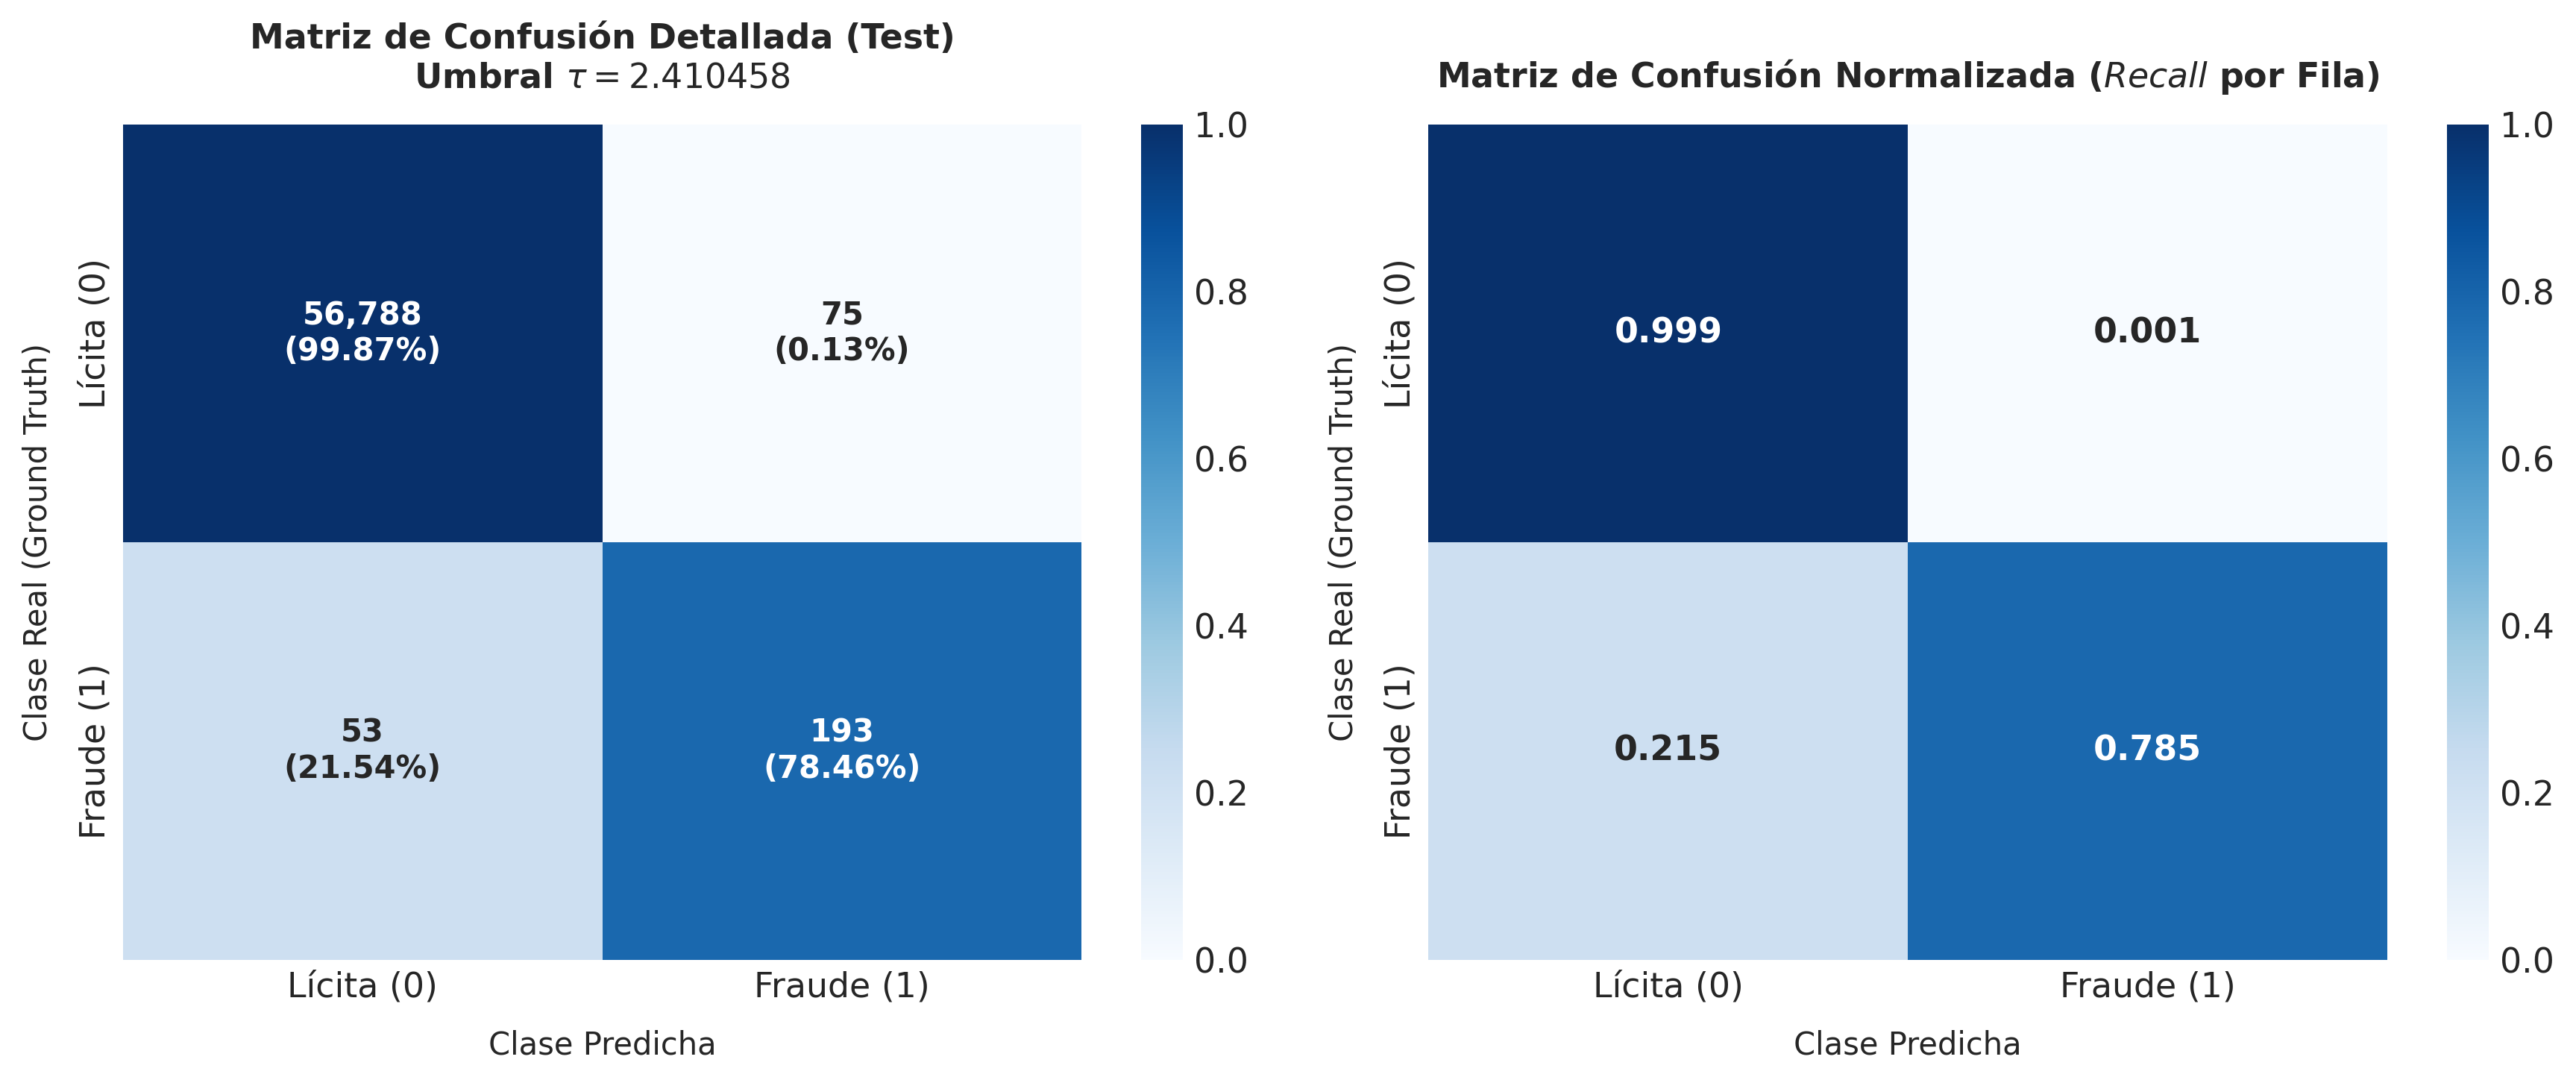

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Estilo global académico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

labels = ["Lícita (0)", "Fraude (1)"]

# --- Subplot 1: Matriz con Conteos + Porcentajes Combinados ---
ax1 = axes[0]

# Construir anotaciones combinadas: Conteo absoluto y Porcentaje por fila
annot_matrix = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = cm_norm[i, j] * 100
        annot_matrix[i, j] = f"{count:,}\n({pct:.2f}%)"

sns.heatmap(
    cm_norm, 
    annot=annot_matrix, 
    fmt="", 
    cmap="Blues", 
    cbar=True, 
    ax=ax1,
    vmin=0, vmax=1,
    xticklabels=labels, 
    yticklabels=labels,
    annot_kws={"size": 10, "weight": "bold"}
)

ax1.set_title(f"Matriz de Confusión Detallada (Test)\nUmbral $\\tau = {optimal_threshold:.6f}$", fontsize=11, fontweight='bold', pad=12)
ax1.set_xlabel("Clase Predicha", fontsize=10, labelpad=8)
ax1.set_ylabel("Clase Real (Ground Truth)", fontsize=10, labelpad=8)

# --- Subplot 2: Rendimiento Relativo Normalizado por Fila ---
ax2 = axes[1]

sns.heatmap(
    cm_norm, 
    annot=True, 
    fmt=".3f", 
    cmap="Blues", 
    cbar=True, 
    ax=ax2,
    vmin=0, vmax=1,
    xticklabels=labels, 
    yticklabels=labels,
    annot_kws={"size": 11, "weight": "bold"}
)

ax2.set_title("Matriz de Confusión Normalizada ($Recall$ por Fila)", fontsize=11, fontweight='bold', pad=12)
ax2.set_xlabel("Clase Predicha", fontsize=10, labelpad=8)
ax2.set_ylabel("Clase Real (Ground Truth)", fontsize=10, labelpad=8)

# Ajustes generales de estética
for ax in axes:
    ax.tick_params(axis='both', which='both', length=0)  # Quitar marcas de ticks

plt.tight_layout()
plt.show()


In [39]:
# ---------------------------------------------------------
# 8. Guardar Artefactos Finales y Configuración
# ---------------------------------------------------------
SEED = 42
threshold_dict = {
    "optimal_threshold": float(optimal_threshold),
    "best_f1_val": float(best_f1),
    "pr_auc_val": float(pr_auc_val),
    "avg_precision_test": float(avg_prec_test),
    "roc_auc_test": float(roc_auc_test),
    "seed": int(SEED)
}

joblib.dump(threshold_dict, PROCESSED_DATA_PATH / "threshold_config.joblib")
np.save(PROCESSED_DATA_PATH / "reconstruction_errors_test.npy", reconstruction_errors_test)
np.save(PROCESSED_DATA_PATH / "y_pred_test.npy", y_pred)

print(f"\n💾 Artefactos guardados exitosamente en: {PROCESSED_DATA_PATH}")
print("   ├─ threshold_config.joblib")
print("   ├─ reconstruction_errors_test.npy")
print("   └─ y_pred_test.npy")


💾 Artefactos guardados exitosamente en: ..\data\processed
   ├─ threshold_config.joblib
   ├─ reconstruction_errors_test.npy
   └─ y_pred_test.npy
